# FMA Music Genre Classification

Systematic evaluation of music genre classification on the Free Music Archive (FMA) dataset across multiple feature representations, split strategies, and model families.

---

## Table of Contents

1. [Configuration](#config)
2. [Data Loading & Exploration](#data-loading)
3. [Feature Engineering](#features)
4. [Split × Feature Dataset Assembly](#splits)
5. [Traditional Models — Full Comparison Grid](#grid)
6. [CNN on Mel Spectrograms](#cnn)
7. [Results Dashboard](#dashboard)
8. [Summary](#summary)

In [ ]:
# ── Dataset ──────────────────────────────────────────────────────────────
DATASET_SIZES = ["small"]
DATASET_SIZES = ["small", "medium"]

# ── Precomputation flags ──────────────────────────────────────────────────
COMPUTE_MFCC           = False   # set True to recompute from audio
COMPUTE_CLAP_FEATURES  = True   # set True to compute CLAP
GENERATE_SPECTROGRAMS  = True   # set True to regenerate mel spectrograms

# ── Feature settings ──────────────────────────────────────────────────────
N_MFCC          = 20             # number of MFCC coefficients
N_COMPONENTS    = 100            # KernelPCA target dimensionality
CLAP_MODEL_NAME = "laion/clap-htsat-unfused"
CLAP_SR         = 48_000         # CLAP requires 48 kHz

# ── Model settings ────────────────────────────────────────────────────────
RUN_CNN         = True           # train CNN on small dataset
RUN_CNN_MEDIUM  = True          # train CNN on medium dataset
N_EPOCHS_SMALL  = 20
N_EPOCHS_MEDIUM = 15
CNN_BATCH_SIZE  = 32

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_ROOT         = "./data"
AUDIO_DIRS        = {sz: f"{DATA_ROOT}/fma_{sz}" for sz in DATASET_SIZES}
MFCC_CSV          = {sz: f"{DATA_ROOT}/mfcc_features_{sz}.csv" for sz in DATASET_SIZES}
CLAP_CSV          = {sz: f"{DATA_ROOT}/clap_features_{sz}.csv" for sz in DATASET_SIZES}
SPECTROGRAM_DIRS  = {sz: f"{DATA_ROOT}/spectrograms_{sz}" for sz in DATASET_SIZES}

In [ ]:
import ast
import json
import os
import time
import warnings
from datetime import date

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as skl
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import Markdown, display
from scipy import stats
from sklearn.base import clone
from sklearn.decomposition import KernelPCA, PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.svm import LinearSVC, SVC
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import librosa

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

import IPython.display as ipd


---
<a id="data-loading"></a>
## 1. Data Loading & Exploration

The [Free Music Archive (FMA)](https://github.com/mdeff/fma) dataset provides:

| File | Description |
|---|---|
| `tracks.csv` | Per-track metadata (genre, dates, set membership) |
| `genres.csv` | Genre hierarchy |
| `features.csv` | 518 precomputed audio features (chroma, tonnetz, spectral, MFCC) |
| `echonest.csv` | Echo Nest social and acoustic features |

In [3]:
def load_fma_metadata(data_root: str):
    """Load FMA metadata CSVs. Returns tracks, genres, features, echonest."""
    with open(f"{data_root}/fma_metadata/genres.csv") as f:
        genres = pd.read_csv(f, index_col=0)

    with open(f"{data_root}/fma_metadata/echonest.csv") as f:
        echonest = pd.read_csv(f, index_col=0, header=[0, 1, 2])

    with open(f"{data_root}/fma_metadata/features.csv") as f:
        features = pd.read_csv(f, index_col=0, header=[0, 1, 2])

    with open(f"{data_root}/fma_metadata/tracks.csv") as f:
        tracks = pd.read_csv(f, index_col=0, header=[0, 1])

    for col in [("track", "tags"), ("album", "tags"), ("artist", "tags"),
                ("track", "genres"), ("track", "genres_all")]:
        tracks[col] = tracks[col].map(ast.literal_eval)

    for col in [("track", "date_created"), ("track", "date_recorded"),
                ("album", "date_created"), ("album", "date_released"),
                ("artist", "date_created"), ("artist", "active_year_begin"),
                ("artist", "active_year_end")]:
        tracks[col] = pd.to_datetime(tracks[col])

    SUBSETS = ("small", "medium", "large")
    tracks["set", "subset"] = tracks["set", "subset"].astype(
        pd.CategoricalDtype(categories=SUBSETS, ordered=True)
    )

    for col in [("track", "genre_top"), ("track", "license"),
                ("album", "type"), ("album", "information"), ("artist", "bio")]:
        tracks[col] = tracks[col].astype("category")

    np.testing.assert_array_equal(features.index, tracks.index)
    assert echonest.index.isin(tracks.index).all()
    return tracks, genres, features, echonest


tracks, genres, features, echonest = load_fma_metadata(DATA_ROOT)
print(f"tracks: {tracks.shape}, genres: {genres.shape}, features: {features.shape}, echonest: {echonest.shape}")

tracks: (106574, 52), genres: (163, 4), features: (106574, 518), echonest: (13129, 249)


In [4]:
print("Track metadata:"); ipd.display(tracks["track"].head(3))
print("Set metadata:");   ipd.display(tracks["set"].head(3))
print("Genre metadata:");  ipd.display(genres.head(3))
print("Features (first 5 cols):"); ipd.display(features.iloc[:3, :5])

Track metadata:


,bit_rate,comments,composer,date_created,date_recorded,duration,favorites,genre_top,genres,genres_all,information,interest,language_code,license,listens,lyricist,number,publisher,tags,title
track_id,,,,,,,,,,,,,,,,,,,,
2,256000,0,NaN,2008-11-26 01:48:12,2008-11-26,168,2,Hip-Hop,[21],[21],NaN,4656,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1293,NaN,3,NaN,[],Food
3,256000,0,NaN,2008-11-26 01:48:14,2008-11-26,237,1,Hip-Hop,[21],[21],NaN,1470,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,514,NaN,4,NaN,[],Electric Ave
5,256000,0,NaN,2008-11-26 01:48:20,2008-11-26,206,6,Hip-Hop,[21],[21],NaN,1933,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1151,NaN,6,NaN,[],This World


Set metadata:


,split,subset
track_id,,
2,training,small
3,training,medium
5,training,small


Genre metadata:


,#tracks,parent,title,top_level
genre_id,,,,
1,8693,38,Avant-Garde,38
2,5271,0,International,2
3,1752,0,Blues,3


Features (first 5 cols):


feature    chroma_cens                                        
statistics    kurtosis                                        
number              01        02        03        04        05
track_id                                                      
2             7.180653  5.230309  0.249321  1.347620  1.482478
3             1.888963  0.760539  0.345297  2.295201  1.654031
5             0.527563 -0.077654 -0.279610  0.685883  1.937570

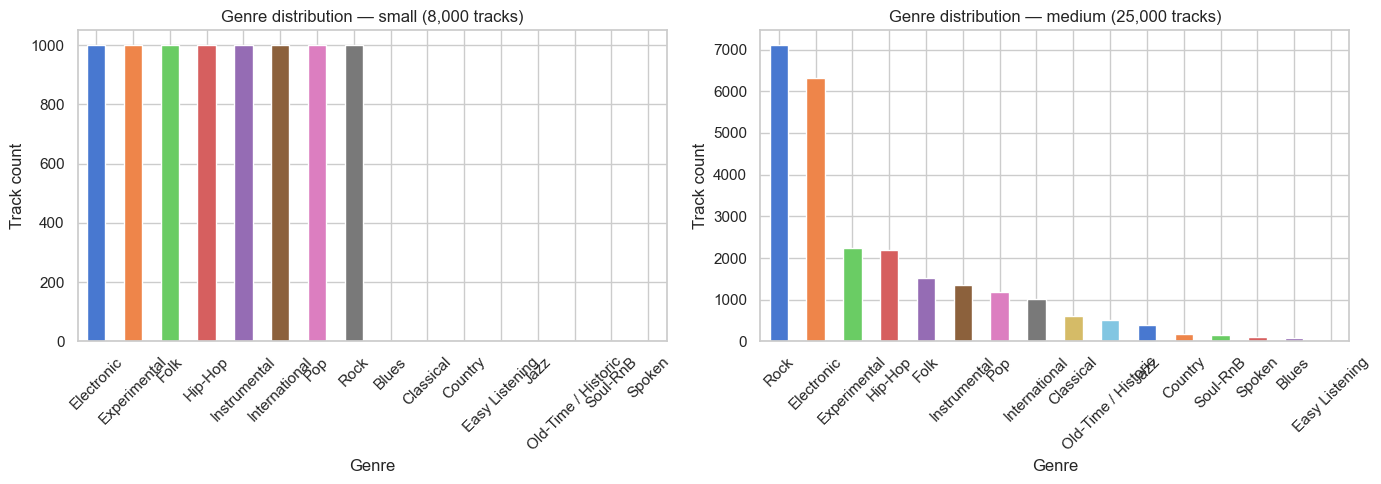

In [5]:
# Genre distribution per dataset size
fig, axes = plt.subplots(1, len(DATASET_SIZES), figsize=(7 * len(DATASET_SIZES), 5), sharey=False)
if len(DATASET_SIZES) == 1:
    axes = [axes]

for ax, sz in zip(axes, DATASET_SIZES):
    subset = tracks[tracks["set", "subset"] <= sz]
    counts = subset["track", "genre_top"].value_counts().dropna()
    counts.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(counts)))
    ax.set_title(f"Genre distribution — {sz} ({len(subset):,} tracks)")
    ax.set_xlabel("Genre")
    ax.set_ylabel("Track count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

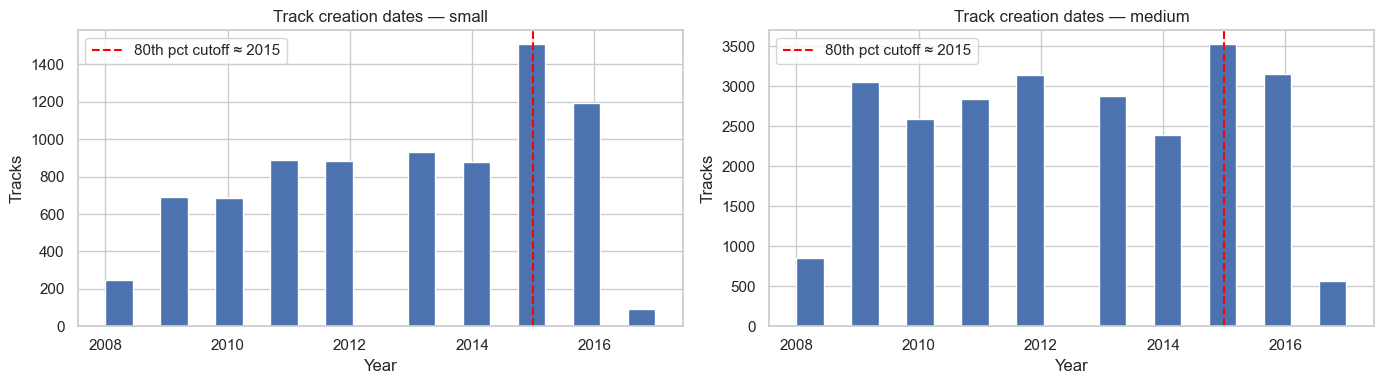

In [6]:
# Track creation date distribution — context for time-based split
fig, axes = plt.subplots(1, len(DATASET_SIZES), figsize=(7 * len(DATASET_SIZES), 4), sharey=False)
if len(DATASET_SIZES) == 1:
    axes = [axes]

for ax, sz in zip(axes, DATASET_SIZES):
    subset = tracks[tracks["set", "subset"] <= sz]
    dates = subset["track", "date_created"].dropna()
    years = dates.dt.year
    cutoff_year = pd.to_datetime(dates.quantile(0.8)).year
    years.hist(bins=20, ax=ax, color="#4C72B0", edgecolor="white")
    ax.axvline(cutoff_year, color="red", linestyle="--", label=f"80th pct cutoff ≈ {cutoff_year}")
    ax.set_title(f"Track creation dates — {sz}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Tracks")
    ax.legend()

plt.tight_layout()
plt.show()

---
<a id="features"></a>
## 2. Feature Engineering

Three feature representations are computed/loaded for each dataset size:

| Feature set | Raw dim | Reduced | Source |
|---|---|---|---|
| MFCC | 140d | 100d (KernelPCA) | librosa — 7 statistics × 20 coefficients |
| Full features | 518d | 100d (KernelPCA) | FMA precomputed CSV (chroma, tonnetz, spectral, MFCC) |
| CLAP embeddings | 512d | 100d (KernelPCA/PCA) | `laion/clap-htsat-unfused` neural embeddings |

### 2a. MFCC Features

**Mel-Frequency Cepstral Coefficients (MFCCs)** capture timbral/textural characteristics of audio.

Pipeline: audio → STFT (n_fft=2048, hop_length=512) → mel spectrogram → log scale → DCT → MFCCs

For each of the 20 coefficients, 7 statistics are computed over time: *mean, std, skew, kurtosis, median, min, max* → **140 dimensions total**.

In [7]:
def get_audio_path(audio_dir: str, track_id: int) -> str:
    tid_str = f"{track_id:06d}"
    return os.path.join(audio_dir, tid_str[:3], tid_str + ".mp3")


def mfcc_columns() -> pd.MultiIndex:
    moments = ("mean", "std", "skew", "kurtosis", "median", "min", "max")
    tuples = [("mfcc", moment, f"{i+1:02d}") for moment in moments for i in range(N_MFCC)]
    return pd.MultiIndex.from_tuples(tuples, names=("feature", "statistics", "number")).sort_values()


def compute_mfcc(tid: int, audio_dir: str) -> pd.Series:
    feat = pd.Series(index=mfcc_columns(), dtype=np.float32, name=tid)
    try:
        x, sr = librosa.load(get_audio_path(audio_dir, tid), sr=None, mono=True)
        stft = np.abs(librosa.stft(x, n_fft=2048, hop_length=512))
        mel = librosa.feature.melspectrogram(sr=sr, S=stft ** 2)
        mfcc = librosa.feature.mfcc(S=librosa.power_to_db(mel), n_mfcc=N_MFCC)
        feat["mfcc", "mean"]     = np.mean(mfcc, axis=1)
        feat["mfcc", "std"]      = np.std(mfcc, axis=1)
        feat["mfcc", "skew"]     = stats.skew(mfcc, axis=1)
        feat["mfcc", "kurtosis"] = stats.kurtosis(mfcc, axis=1)
        feat["mfcc", "median"]   = np.median(mfcc, axis=1)
        feat["mfcc", "min"]      = np.min(mfcc, axis=1)
        feat["mfcc", "max"]      = np.max(mfcc, axis=1)
    except Exception as e:
        print(f"{tid}: {repr(e)}")
    return feat

In [8]:
mfcc_features = {}

for sz in DATASET_SIZES:
    filtered = tracks[tracks["set", "subset"] <= sz]
    tids = filtered.index

    if COMPUTE_MFCC:
        df = pd.DataFrame(index=tids, columns=mfcc_columns(), dtype=np.float32)
        for tid in tqdm(tids, desc=f"MFCC [{sz}]"):
            df.loc[tid] = compute_mfcc(tid, AUDIO_DIRS[sz])
        df.sort_index(axis=0, inplace=True)
        df.sort_index(axis=1, inplace=True)
        df.to_csv(MFCC_CSV[sz], float_format="%.10e")
        mfcc_features[sz] = df
    else:
        mfcc_features[sz] = pd.read_csv(MFCC_CSV[sz], index_col=0, header=[0, 1, 2])

    print(f"[{sz}] MFCC shape: {mfcc_features[sz].shape}")

[small] MFCC shape: (8000, 140)
[medium] MFCC shape: (25000, 140)


In [9]:
# Drop tracks with missing MFCC values and exclude Instrumental genre
cleaned_tracks = {}
cleaned_mfcc   = {}
X_full         = {}

for sz in DATASET_SIZES:
    filtered = tracks[tracks["set", "subset"] <= sz]
    mf = mfcc_features[sz]

    mask_na  = mf.isna().any(axis=1)
    mask_ins = filtered.loc[mf.index, ("track", "genre_top")] == "Instrumental"
    mask_bad = mask_na | mask_ins.reindex(mf.index, fill_value=False)

    ct = filtered.loc[mf.index][~mask_bad]
    cleaned_tracks[sz] = ct
    cleaned_mfcc[sz]   = mf[~mask_bad]
    X_full[sz]         = features.loc[ct.index].values

    print(f"[{sz}] tracks: {len(ct)}, missing MFCC: {mask_na.sum()}, genres: {ct['track','genre_top'].nunique()}")

[small] tracks: 6997, missing MFCC: 4, genres: 7
[medium] tracks: 23634, missing MFCC: 18, genres: 15


### 2b. Precomputed FMA Features (518d)

The FMA `features.csv` provides 518 pre-computed audio descriptors covering:
chroma CQT/CENs, spectral contrast/centroid/bandwidth/rolloff, MFCC, RMS energy, tonnetz, and zero-crossing rate.
These are already aligned to the full tracks index and are loaded once above via `load_fma_metadata()`.

### 2c. CLAP Embeddings (512d)

**CLAP** (Contrastive Language-Audio Pretraining) produces dense 512-dimensional audio embeddings from the `laion/clap-htsat-unfused` model.
Audio is resampled to 48 kHz before inference. Embeddings capture high-level semantic content beyond hand-crafted statistics.

In [10]:
clap_features = {}

if COMPUTE_CLAP_FEATURES:
    import torch as _torch
    from transformers import ClapModel, ClapProcessor

    _clap_device = _torch.device("cuda" if _torch.cuda.is_available() else "cpu")
    print(f"Loading CLAP on {_clap_device}...")
    _clap_model = ClapModel.from_pretrained(CLAP_MODEL_NAME).to(_clap_device).eval()
    _clap_proc  = ClapProcessor.from_pretrained(CLAP_MODEL_NAME)

    CLAP_BATCH_SIZE = 16  # increase if you have more RAM/VRAM

    def _load_audio(tid: int, audio_dir: str):
        try:
            audio, _ = librosa.load(get_audio_path(audio_dir, tid), sr=CLAP_SR, mono=True)
            return tid, audio
        except Exception as e:
            print(f"{tid}: {repr(e)}")
            return tid, None

    def _embed_batch(tids, audios):
        inp = _clap_proc(
            audio=audios,
            return_tensors="pt",
            sampling_rate=CLAP_SR,
            padding=True,
        ).to(_clap_device)
        with _torch.no_grad():
            out = _clap_model.audio_model(
                input_features=inp["input_features"],
                is_longer=inp.get("is_longer"),
            )
            embs = _clap_model.audio_projection(out.pooler_output).cpu().numpy()
        return embs  # shape (batch, 512)

    for sz in DATASET_SIZES:
        ct = cleaned_tracks[sz]
        rows = {}
        batch_tids, batch_audios = [], []

        for tid in tqdm(list(ct.index), desc=f"CLAP [{sz}]"):
            tid_val, audio = _load_audio(tid, AUDIO_DIRS[sz])
            if audio is None:
                continue
            batch_tids.append(tid_val)
            batch_audios.append(audio)

            if len(batch_tids) >= CLAP_BATCH_SIZE:
                embs = _embed_batch(batch_tids, batch_audios)
                for t, e in zip(batch_tids, embs):
                    rows[t] = e
                batch_tids, batch_audios = [], []

        if batch_tids:
            embs = _embed_batch(batch_tids, batch_audios)
            for t, e in zip(batch_tids, embs):
                rows[t] = e

        df = pd.DataFrame.from_dict(rows, orient="index")
        df.index.name = "track_id"
        df.to_csv(CLAP_CSV[sz], float_format="%.8e")
        clap_features[sz] = df
        print(f"[{sz}] CLAP saved: {df.shape}")
else:
    for sz in DATASET_SIZES:
        try:
            df = pd.read_csv(CLAP_CSV[sz], index_col=0)
            clap_features[sz] = df.loc[df.index.isin(cleaned_tracks[sz].index)]
            print(f"[{sz}] Loaded CLAP: {clap_features[sz].shape}")
        except FileNotFoundError:
            print(f"[{sz}] No CLAP file found at {CLAP_CSV[sz]}. Set COMPUTE_CLAP_FEATURES=True.")
            clap_features[sz] = None


[small] Loaded CLAP: (6997, 512)
[medium] No CLAP file found at ./data/clap_features_medium.csv. Set COMPUTE_CLAP_FEATURES=True.


### 2d. Feature Visualization (t-SNE, small dataset)

2D t-SNE projections of MFCC and CLAP embeddings (small dataset, Hip-Hop vs Instrumental for clarity).

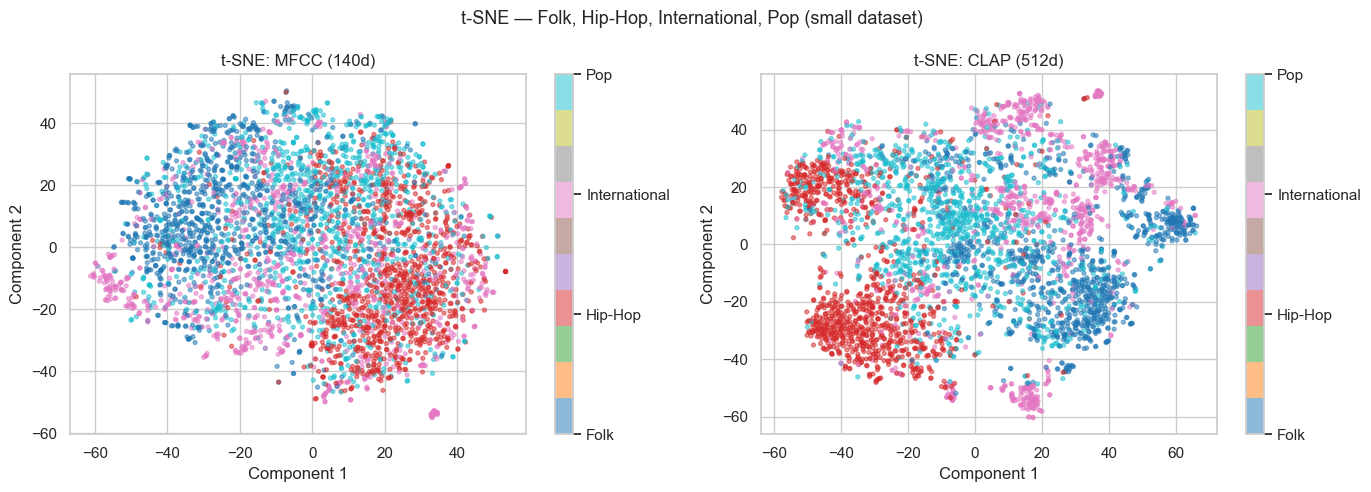

In [11]:
_sz = "small"
_ct = cleaned_tracks[_sz]

# Use value_counts so we only pick genres that actually exist in this subset
_genres_vis = _ct["track", "genre_top"].value_counts().index.tolist()[:4]
_mask = _ct["track", "genre_top"].isin(_genres_vis)

# Align mfcc on the same index as cleaned_tracks
_idx_vis = _ct.index[_mask]
_y_vis  = _ct.loc[_idx_vis, ("track", "genre_top")].values
_le_vis = LabelEncoder().fit(_y_vis)
_y_enc  = _le_vis.transform(_y_vis)

_mfcc_vis   = cleaned_mfcc[_sz].loc[_idx_vis, "mfcc"].values
_mfcc_scaled = StandardScaler().fit_transform(_mfcc_vis)
_tsne_mfcc   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(_mfcc_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(_tsne_mfcc[:, 0], _tsne_mfcc[:, 1], c=_y_enc, cmap="tab10", alpha=0.5, s=8)
axes[0].set_title("t-SNE: MFCC (140d)")
axes[0].set_xlabel("Component 1"); axes[0].set_ylabel("Component 2")
plt.colorbar(sc0, ax=axes[0], ticks=range(len(_le_vis.classes_))).set_ticklabels(_le_vis.classes_)

if clap_features.get(_sz) is not None:
    _clap_idx = _idx_vis[_idx_vis.isin(clap_features[_sz].index)]
    _clap_vis = clap_features[_sz].loc[_clap_idx].values
    _y_clap   = _le_vis.transform(_ct.loc[_clap_idx, ("track", "genre_top")].values)
    _tsne_clap = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(_clap_vis)
    sc1 = axes[1].scatter(_tsne_clap[:, 0], _tsne_clap[:, 1], c=_y_clap, cmap="tab10", alpha=0.5, s=8)
    axes[1].set_title("t-SNE: CLAP (512d)")
    axes[1].set_xlabel("Component 1"); axes[1].set_ylabel("Component 2")
    plt.colorbar(sc1, ax=axes[1], ticks=range(len(_le_vis.classes_))).set_ticklabels(_le_vis.classes_)
else:
    axes[1].set_title("CLAP not available"); axes[1].axis("off")

plt.suptitle(f"t-SNE — {', '.join(_genres_vis)} (small dataset)", fontsize=13)
plt.tight_layout()
plt.show()

---
<a id="splits"></a>
## 3. Split × Feature Dataset Assembly

Two holdout strategies are applied to every feature × dataset-size combination:

| Strategy | Method |
|---|---|
| **Random** | Stratified 80/20 split, `random_state=42` |
| **Time-based** | 80th-percentile `date_created` cutoff (Simulates deployment on future music) |

In [12]:
def make_random_split(X, y, test_size=0.2, seed=42):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)
    return {"X_train": Xtr, "X_test": Xte, "y_train": ytr, "y_test": yte}


def make_time_split(X, y, dates, quantile=0.8):
    cutoff = dates.quantile(quantile)
    idx_tr = np.where(dates.values <= cutoff)[0]
    idx_te = np.where(dates.values > cutoff)[0]
    return {
        "X_train": X[idx_tr], "X_test": X[idx_te],
        "y_train": y[idx_tr], "y_test": y[idx_te],
    }

In [13]:
# Build all_datasets[(sz, split, feature)] = {X_train, X_test, y_train, y_test}
all_datasets = {}

for sz in DATASET_SIZES:
    ct    = cleaned_tracks[sz]
    y_all = ct["track", "genre_top"].values
    dates = ct["track", "date_created"]

    feature_map = {
        "MFCC (140d)": cleaned_mfcc[sz]["mfcc"].values,
        "Full (518d)": X_full[sz],
    }
    if clap_features.get(sz) is not None:
        ct_clap   = ct.loc[ct.index.isin(clap_features[sz].index)]
        X_clap    = clap_features[sz].loc[ct_clap.index].values
        y_clap    = ct_clap["track", "genre_top"].values
        dates_clap = ct_clap["track", "date_created"]
        feature_map["CLAP (512d)"] = (X_clap, y_clap, dates_clap)  # tuple signals separate y/dates

    for feat_name, feat_data in feature_map.items():
        if isinstance(feat_data, tuple):
            X_raw, y_local, dates_local = feat_data
        else:
            X_raw, y_local, dates_local = feat_data, y_all, dates

        all_datasets[(sz, "random", feat_name)] = make_random_split(X_raw, y_local)
        all_datasets[(sz, "time",   feat_name)] = make_time_split(X_raw, y_local, dates_local)

print(f"Total dataset variants: {len(all_datasets)}")
print(f"Expected: {len(DATASET_SIZES)} sizes × 2 splits × up to 3 features")
for k, d in sorted(all_datasets.items()):
    print(f"  {k}: train={len(d['X_train']):5d}, test={len(d['X_test']):4d}")

Total dataset variants: 10
Expected: 2 sizes × 2 splits × up to 3 features
  ('medium', 'random', 'Full (518d)'): train=18907, test=4727
  ('medium', 'random', 'MFCC (140d)'): train=18907, test=4727
  ('medium', 'time', 'Full (518d)'): train=18907, test=4727
  ('medium', 'time', 'MFCC (140d)'): train=18907, test=4727
  ('small', 'random', 'CLAP (512d)'): train= 5597, test=1400
  ('small', 'random', 'Full (518d)'): train= 5597, test=1400
  ('small', 'random', 'MFCC (140d)'): train= 5597, test=1400
  ('small', 'time', 'CLAP (512d)'): train= 5597, test=1400
  ('small', 'time', 'Full (518d)'): train= 5597, test=1400
  ('small', 'time', 'MFCC (140d)'): train= 5597, test=1400


In [14]:
# KernelPCA dimensionality reduction (fit on train only)
# Note: KernelPCA with RBF builds an n×n kernel matrix.
# For medium+Full (518d, ~20k samples) this can be slow/memory-heavy.
# In that case we fall back to linear PCA automatically.
reduced_datasets = {}
MEDIUM_KPCA_FALLBACK_THRESHOLD = 15_000   # switch to PCA above this many training samples

for key, data in all_datasets.items():
    sz, split, feat = key
    X_tr, X_te = data["X_train"], data["X_test"]
    y_tr, y_te = data["y_train"], data["y_test"]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    n_comp = min(N_COMPONENTS, X_tr_s.shape[1])

    use_pca = len(X_tr_s) > MEDIUM_KPCA_FALLBACK_THRESHOLD
    if use_pca:
        reducer = PCA(n_components=n_comp, random_state=42)
        label = "PCA"
    else:
        reducer = KernelPCA(n_components=n_comp, kernel="rbf", random_state=42, n_jobs=-1)
        label = "KernelPCA"

    X_tr_r = reducer.fit_transform(X_tr_s)
    X_te_r = reducer.transform(X_te_s)

    reduced_datasets[key] = {
        "X_train": X_tr_r, "X_test": X_te_r,
        "y_train": y_tr,   "y_test": y_te,
        "reducer": label,
    }

print("Reduction complete.")
for key, d in sorted(reduced_datasets.items()):
    print(f"  {key}: {d['X_train'].shape[1]}d ({d['reducer']})")

Reduction complete.
  ('medium', 'random', 'Full (518d)'): 100d (PCA)
  ('medium', 'random', 'MFCC (140d)'): 100d (PCA)
  ('medium', 'time', 'Full (518d)'): 100d (PCA)
  ('medium', 'time', 'MFCC (140d)'): 100d (PCA)
  ('small', 'random', 'CLAP (512d)'): 100d (KernelPCA)
  ('small', 'random', 'Full (518d)'): 100d (KernelPCA)
  ('small', 'random', 'MFCC (140d)'): 100d (KernelPCA)
  ('small', 'time', 'CLAP (512d)'): 100d (KernelPCA)
  ('small', 'time', 'Full (518d)'): 100d (KernelPCA)
  ('small', 'time', 'MFCC (140d)'): 100d (KernelPCA)


In [15]:
# Train/test size summary with class balance
rows = []
for (sz, split, feat), d in sorted(all_datasets.items()):
    for partition, y in [("train", d["y_train"]), ("test", d["y_test"])]:
        vals, cnts = np.unique(y, return_counts=True)
        majority_pct = cnts.max() / cnts.sum() * 100
        rows.append({"Dataset": sz, "Split": split, "Features": feat,
                     "Partition": partition, "N": len(y),
                     "Majority class %": round(majority_pct, 1)})

summary_splits = pd.DataFrame(rows)
display(summary_splits.pivot_table(
    index=["Dataset", "Features", "Split"],
    columns="Partition", values=["N", "Majority class %"]
).round(1))

Majority class %             N         
Partition                              test train    test    train
Dataset Features    Split                                         
medium  Full (518d) random             30.0  30.0  4727.0  18907.0
                    time               33.6  29.1  4727.0  18907.0
        MFCC (140d) random             30.0  30.0  4727.0  18907.0
                    time               33.6  29.1  4727.0  18907.0
small   CLAP (512d) random             14.3  14.3  1400.0   5597.0
                    time               17.8  15.3  1400.0   5597.0
        Full (518d) random             14.3  14.3  1400.0   5597.0
                    time               17.8  15.3  1400.0   5597.0
        MFCC (140d) random             14.3  14.3  1400.0   5597.0
                    time               17.8  15.3  1400.0   5597.0

---
<a id="grid"></a>
## 4. Traditional Models — Full Comparison Grid

| Dimension | Values |
|---|---|
| Models | Logistic Regression, Random Forest, SVM, LightGBM |
| Feature sets | MFCC (140d), Full (518d), CLAP (512d) |
| Splits | random, time |
| Dataset sizes | small, medium |
| **Total rows** | **up to 4 × 3 × 2 × 2 = 48** |

In [16]:
from sklearn.ensemble import RandomForestClassifier 
def _make_svm(sz: str):
    """Return RBF SVC for small, LinearSVC wrapper for medium."""
    if sz == "small":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, random_state=42)),
        ])
    # LinearSVC doesn't support predict_proba natively; wrap with CalibratedClassifierCV
    from sklearn.calibration import CalibratedClassifierCV
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))),
    ])


def get_model_definitions(sz: str) -> dict:
    return {
        "Logistic Regression": LogisticRegression(
            solver="lbfgs", max_iter=1000, C=1.0, random_state=42, n_jobs=-1,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=500, random_state=42, n_jobs=-1,
        ),
        "SVM": _make_svm(sz),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            random_state=42, n_jobs=-1, verbose=-1,
        ),
    }

In [17]:
def evaluate_model(model, X_train, X_test, y_train, y_test) -> dict:
    """Fit model, evaluate, and return a result dict compatible with master_df schema."""    
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    classes = np.sort(np.unique(np.concatenate([y_train, y_test])))
    y_bin   = label_binarize(y_test, classes=classes)

    per_cls_f1 = dict(zip(
        classes.tolist(),
        f1_score(y_test, y_pred, average=None, labels=classes).round(4).tolist()
    ))

    return {
        "f1_macro":        round(f1_score(y_test, y_pred, average="macro"), 4),
        "auroc_macro":     round(roc_auc_score(y_bin, y_proba, average="macro", multi_class="ovr"), 4),
        "precision_macro": round(precision_score(y_test, y_pred, average="macro"), 4),
        "recall_macro":    round(recall_score(y_test, y_pred, average="macro"), 4),
        "train_time_s":    round(train_time, 2),
        "n_train":         len(y_train),
        "n_test":          len(y_test),
        "per_class_f1":    json.dumps(per_cls_f1),
        "_y_pred":         y_pred,
        "_y_proba":        y_proba,
        "_classes":        classes,
        "_model":          model,
    }

In [18]:
all_results = []
fitted_grid = {}   # (sz, split, feat, model) -> result dict

keys = sorted(reduced_datasets.keys())
for key in tqdm(keys, desc="Training"):
    sz, split, feat = key
    data = reduced_datasets[key]
    models = get_model_definitions(sz)

    for model_name, model_tmpl in models.items():
        res = evaluate_model(
            clone(model_tmpl),
            data["X_train"], data["X_test"],
            data["y_train"], data["y_test"],
        )
        row = {k: v for k, v in res.items() if not k.startswith("_")}
        row.update({"dataset": sz, "split": split, "features": feat, "model": model_name,
                    "features_dim_raw": data["X_train"].shape[1],
                    "features_dim_reduced": data["X_train"].shape[1]})
        all_results.append(row)
        fitted_grid[(sz, split, feat, model_name)] = res

results_df = pd.DataFrame(all_results)
print(f"Results: {len(results_df)} rows")
display(
    results_df.sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
    .style.format({"f1_macro": "{:.3f}", "auroc_macro": "{:.3f}",
                   "precision_macro": "{:.3f}", "recall_macro": "{:.3f}",
                   "train_time_s": "{:.1f}"}, na_rep="-")
    .background_gradient(subset=["f1_macro", "auroc_macro"], cmap="YlGn")
    .set_caption("Traditional Models — All Combinations")
)

Training: 100%|██████████| 10/10 [09:45<00:00, 58.58s/it]

Results: 40 rows


,f1_macro,auroc_macro,precision_macro,recall_macro,train_time_s,n_train,n_test,per_class_f1,dataset,split,features,model,features_dim_raw,features_dim_reduced
0,0.692,0.924,0.692,0.693,5.0,5597,1400,"{""Electronic"": 0.7105, ""Experimental"": 0.6434, ""Folk"": 0.7192, ""Hip-Hop"": 0.77, ""International"": 0.7861, ""Pop"": 0.4667, ""Rock"": 0.7494}",small,random,CLAP (512d),SVM,100,100
1,0.685,0.918,0.685,0.689,27.4,5597,1400,"{""Electronic"": 0.7231, ""Experimental"": 0.6565, ""Folk"": 0.7164, ""Hip-Hop"": 0.7644, ""International"": 0.782, ""Pop"": 0.4162, ""Rock"": 0.7386}",small,random,CLAP (512d),LightGBM,100,100
2,0.671,0.921,0.673,0.674,1.6,5597,1400,"{""Electronic"": 0.6904, ""Experimental"": 0.6649, ""Folk"": 0.726, ""Hip-Hop"": 0.7487, ""International"": 0.715, ""Pop"": 0.4022, ""Rock"": 0.7494}",small,random,CLAP (512d),Random Forest,100,100
3,0.669,0.917,0.668,0.674,0.0,5597,1400,"{""Electronic"": 0.6905, ""Experimental"": 0.6667, ""Folk"": 0.7174, ""Hip-Hop"": 0.7513, ""International"": 0.7111, ""Pop"": 0.4113, ""Rock"": 0.7366}",small,random,CLAP (512d),Logistic Regression,100,100
4,0.663,0.918,0.661,0.671,0.0,5597,1400,"{""Electronic"": 0.7392, ""Experimental"": 0.6092, ""Folk"": 0.6372, ""Hip-Hop"": 0.8199, ""International"": 0.7205, ""Pop"": 0.3991, ""Rock"": 0.7175}",small,time,CLAP (512d),Logistic Regression,100,100
5,0.656,0.904,0.653,0.661,27.4,5597,1400,"{""Electronic"": 0.7254, ""Experimental"": 0.6019, ""Folk"": 0.6468, ""Hip-Hop"": 0.8204, ""International"": 0.6821, ""Pop"": 0.387, ""Rock"": 0.7273}",small,time,CLAP (512d),LightGBM,100,100
6,0.652,0.914,0.654,0.659,1.9,5597,1400,"{""Electronic"": 0.7325, ""Experimental"": 0.6098, ""Folk"": 0.6591, ""Hip-Hop"": 0.8038, ""International"": 0.6475, ""Pop"": 0.4036, ""Rock"": 0.708}",small,time,CLAP (512d),Random Forest,100,100
7,0.631,0.894,0.632,0.631,6.2,5597,1400,"{""Electronic"": 0.6115, ""Experimental"": 0.6062, ""Folk"": 0.7181, ""Hip-Hop"": 0.639, ""International"": 0.7208, ""Pop"": 0.4253, ""Rock"": 0.6972}",small,random,Full (518d),SVM,100,100
8,0.630,0.899,0.631,0.633,4.9,5597,1400,"{""Electronic"": 0.6767, ""Experimental"": 0.5732, ""Folk"": 0.6267, ""Hip-Hop"": 0.8019, ""International"": 0.6781, ""Pop"": 0.3856, ""Rock"": 0.6695}",small,time,CLAP (512d),SVM,100,100
9,0.583,0.879,0.581,0.586,31.1,5597,1400,"{""Electronic"": 0.5578, ""Experimental"": 0.5481, ""Folk"": 0.6998, ""Hip-Hop"": 0.5799, ""International"": 0.6821, ""Pop"": 0.3262, ""Rock"": 0.6849}",small,random,Full (518d),LightGBM,100,100


### 4a. Per-Split Analysis

In [19]:
pivot_split = results_df.groupby(["features", "split"])["f1_macro"].mean().unstack("split")
print("Mean F1 (macro) by feature set and split strategy:")
display(pivot_split.style.format("{:.3f}").background_gradient(cmap="YlGn"))

Mean F1 (macro) by feature set and split strategy:


split,random,time
features,,
CLAP (512d),0.679,0.650
Full (518d),0.487,0.429
MFCC (140d),0.433,0.390


### 4b. Per-Feature Analysis

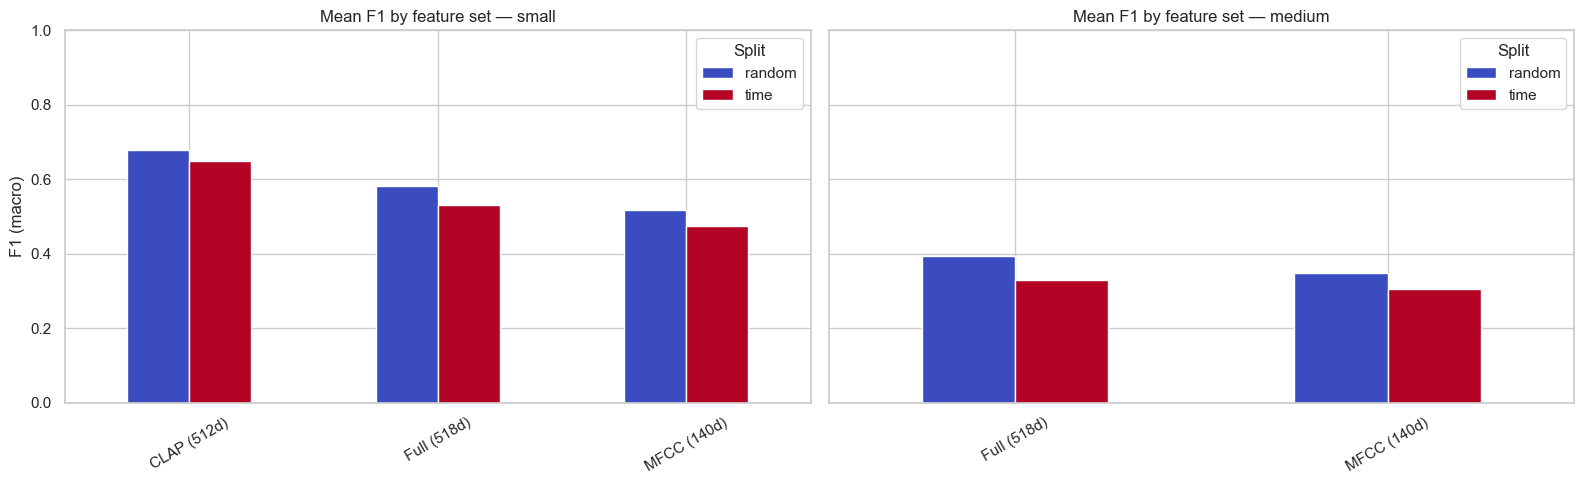

In [20]:
fig, axes = plt.subplots(1, len(DATASET_SIZES), figsize=(8 * len(DATASET_SIZES), 5), sharey=True)
if len(DATASET_SIZES) == 1:
    axes = [axes]

for ax, sz in zip(axes, DATASET_SIZES):
    sub = results_df[results_df["dataset"] == sz]
    pivot = sub.groupby(["features", "split"])["f1_macro"].mean().unstack("split")
    pivot.plot(kind="bar", ax=ax, colormap="coolwarm", edgecolor="white")
    ax.set_title(f"Mean F1 by feature set — {sz}")
    ax.set_ylabel("F1 (macro)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Split")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 4c. Confusion Matrices — Best Model per Feature × Split (small dataset)

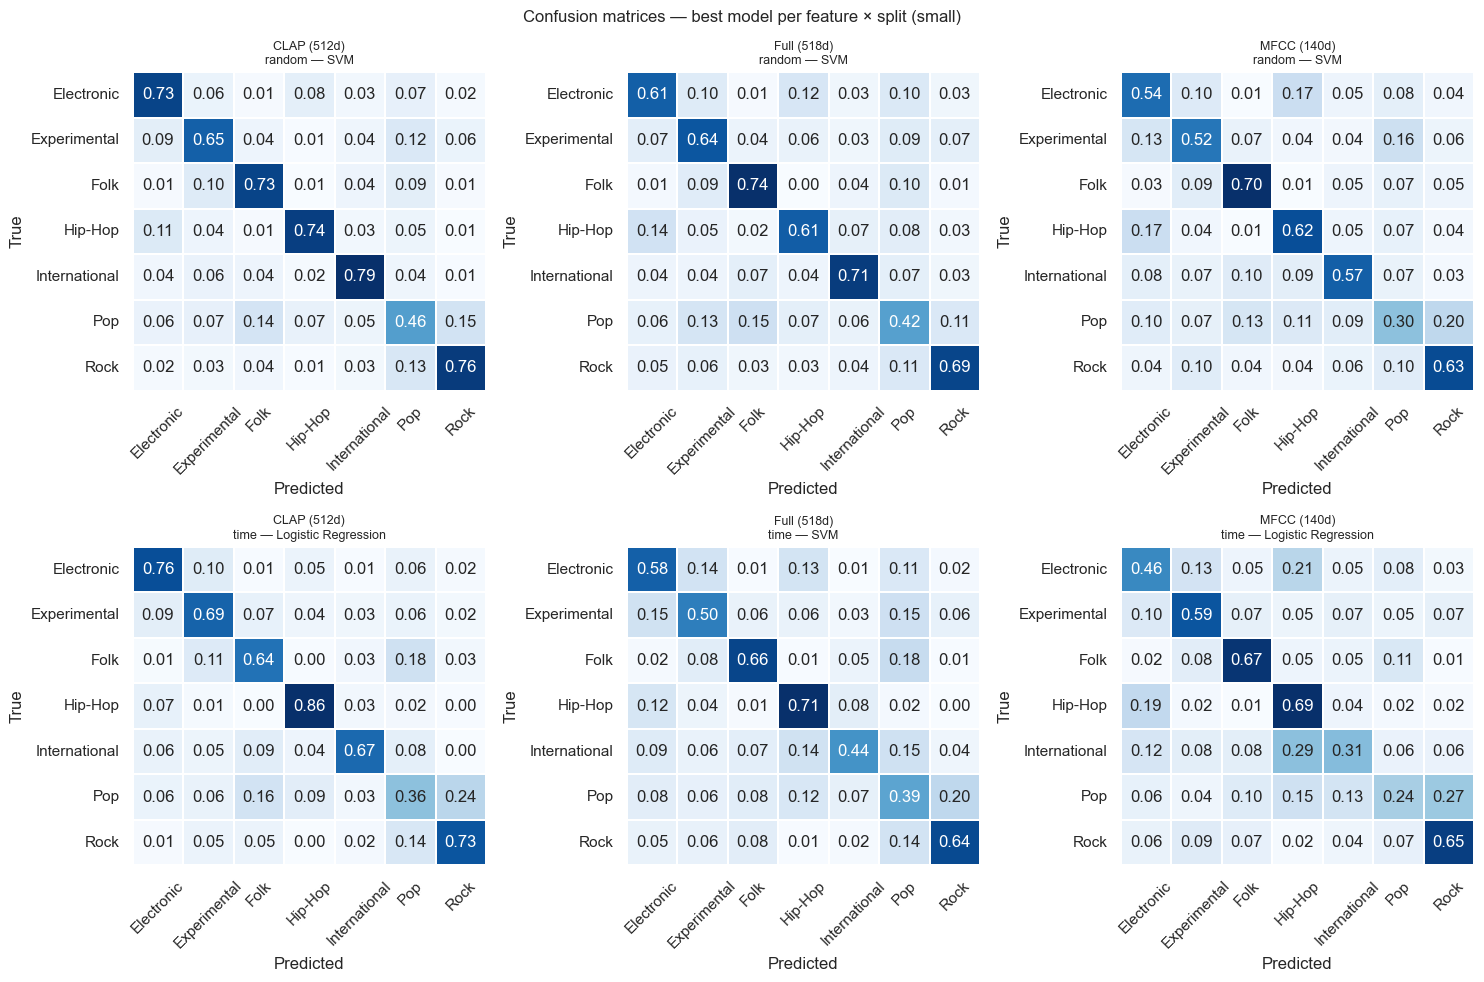

In [21]:
_sz = "small"
_sub = results_df[results_df["dataset"] == _sz]
_feats = sorted(_sub["features"].unique())
_splits = ["random", "time"]

fig, axes = plt.subplots(len(_splits), len(_feats), figsize=(5 * len(_feats), 5 * len(_splits)))
if axes.ndim == 1:
    axes = axes.reshape(1, -1)

for row_i, split in enumerate(_splits):
    for col_j, feat in enumerate(_feats):
        ax = axes[row_i, col_j]
        sub2 = _sub[(_sub["split"] == split) & (_sub["features"] == feat)]
        if sub2.empty:
            ax.set_visible(False); continue
        best_model = sub2.loc[sub2["f1_macro"].idxmax(), "model"]
        res = fitted_grid.get((_sz, split, feat, best_model))
        if res is None:
            ax.set_title(f"{feat}\n{split} — no data"); ax.axis("off"); continue

        y_test  = reduced_datasets[(_sz, split, feat)]["y_test"]
        y_pred  = res["_y_pred"]
        classes = res["_classes"]
        cm_norm = confusion_matrix(y_test, y_pred, labels=classes, normalize="true")

        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=classes, yticklabels=classes,
                    ax=ax, cbar=False, linewidths=0.3)
        ax.set_title(f"{feat}\n{split} — {best_model}", fontsize=9)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.tick_params(axis="x", rotation=45)

plt.suptitle("Confusion matrices — best model per feature × split (small)", fontsize=12)
plt.tight_layout()
plt.show()

### 4d. Per-Class F1 Heatmap

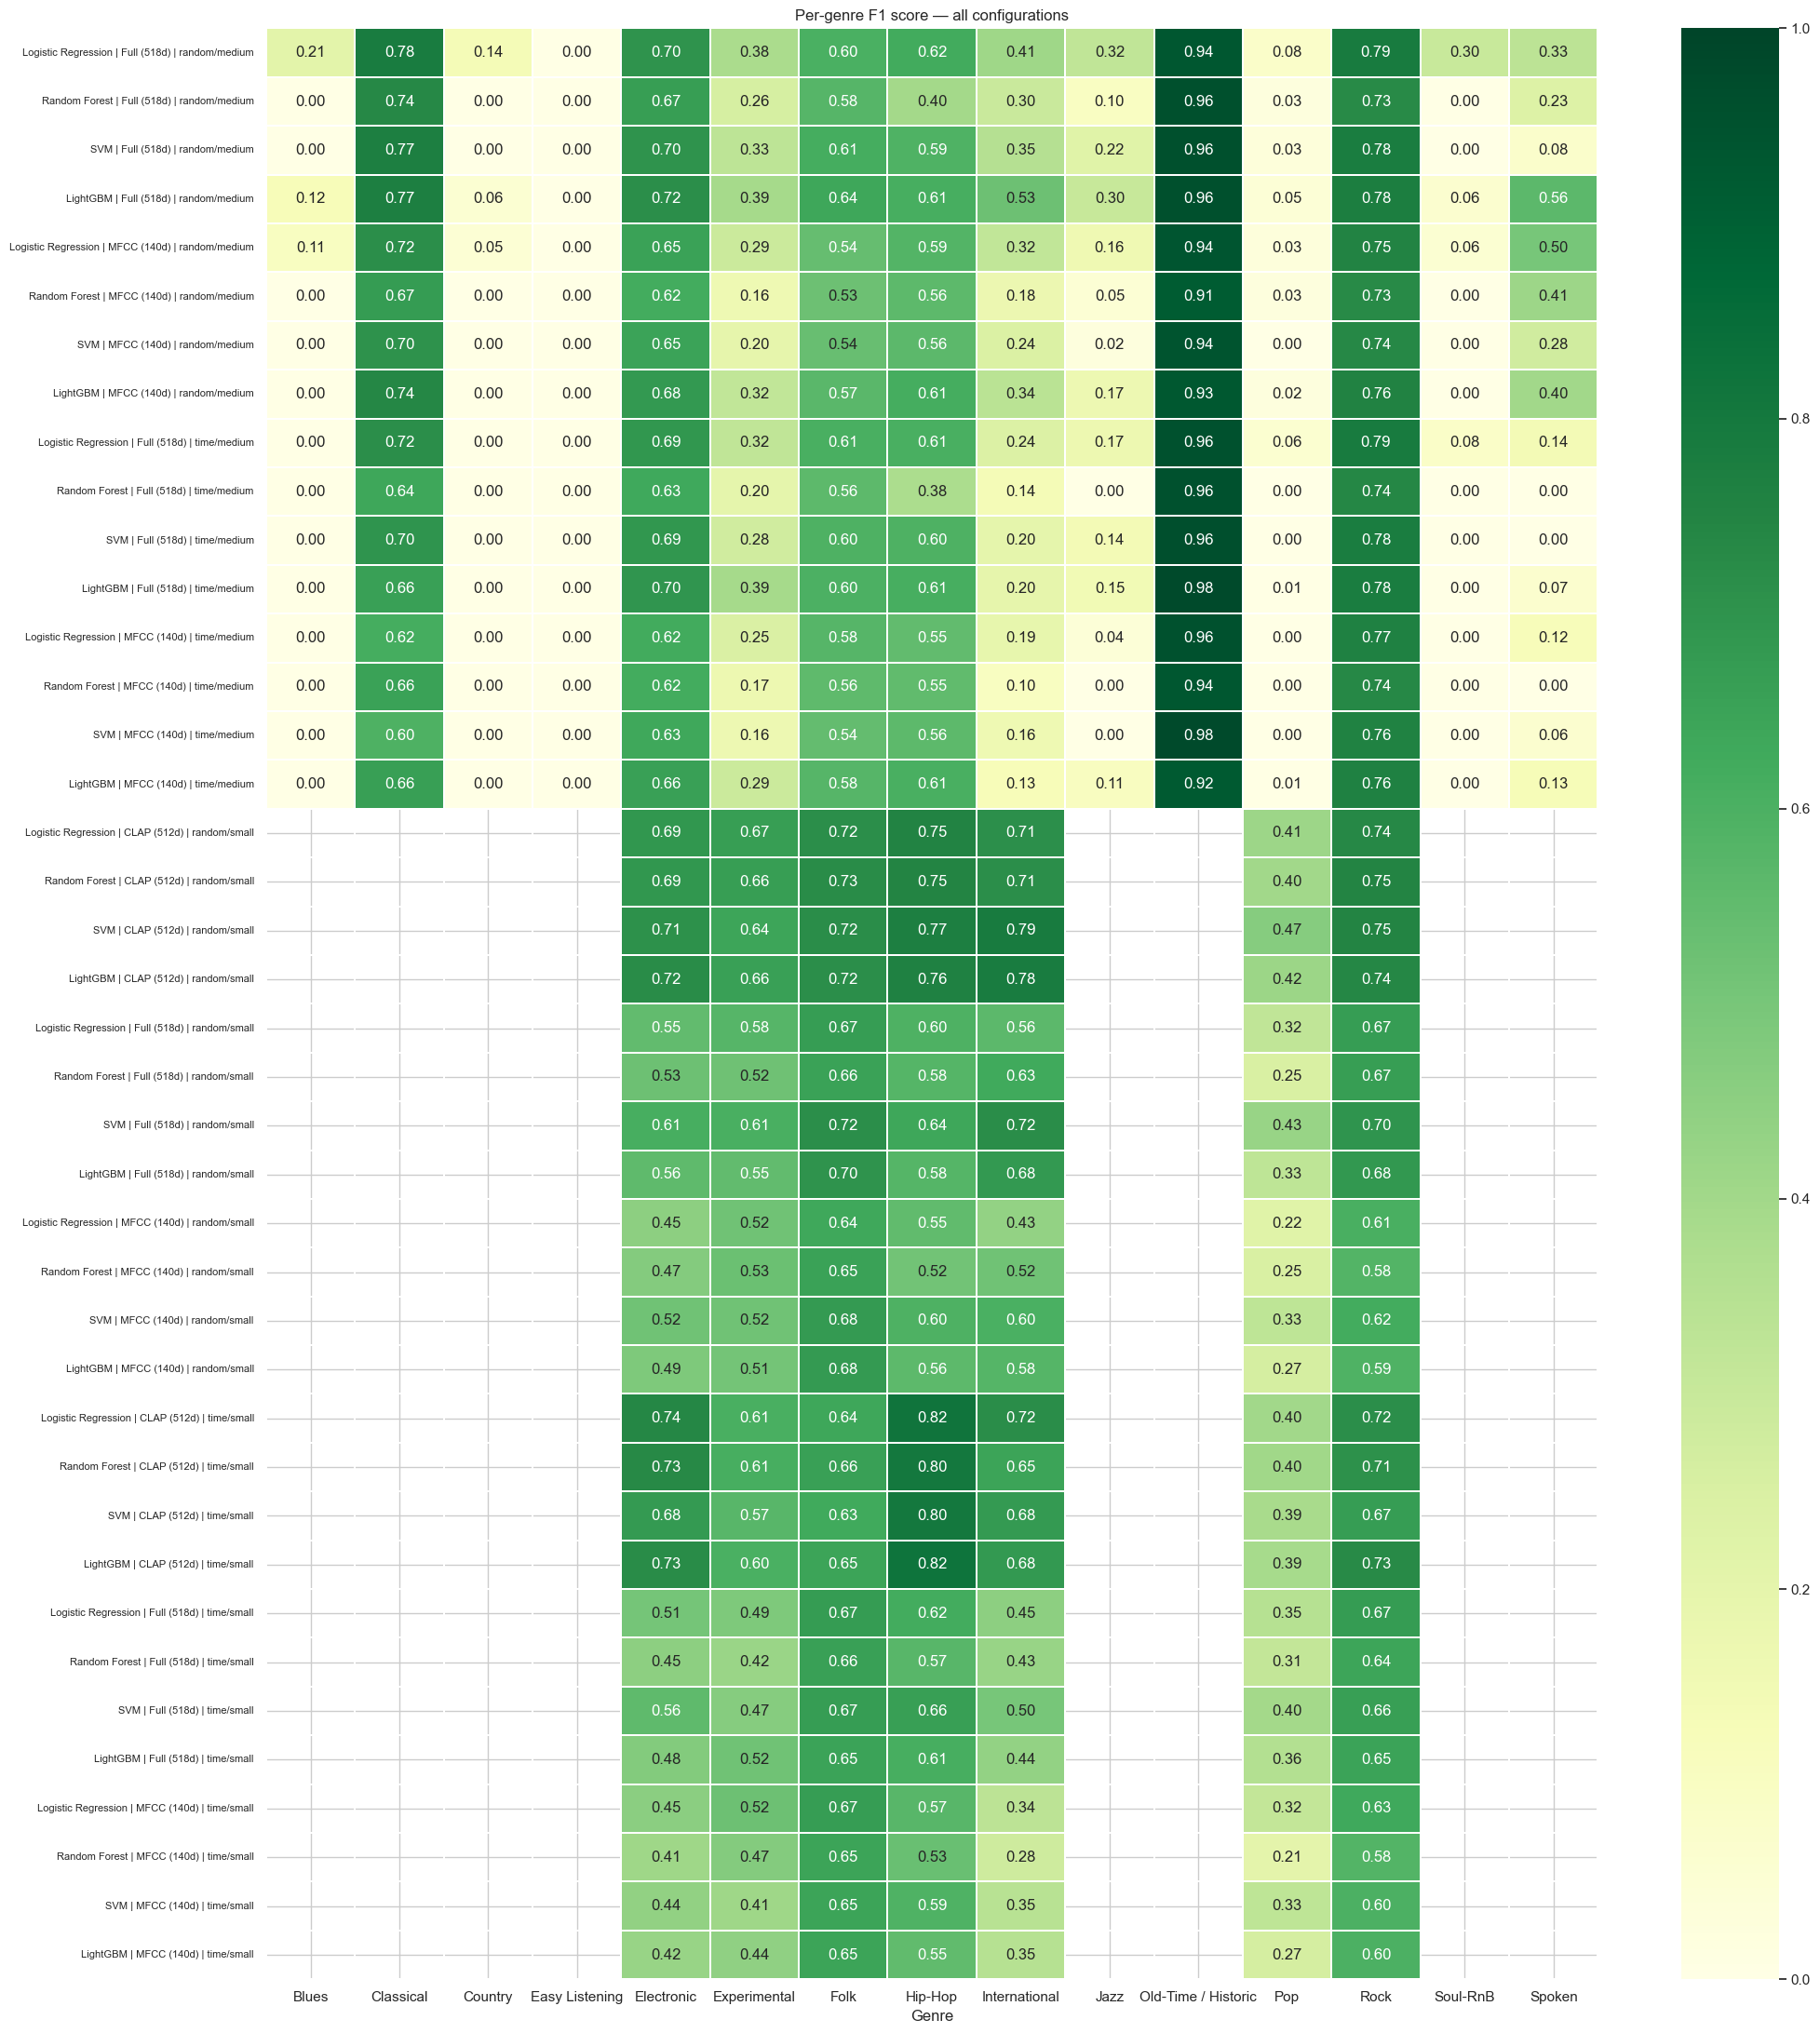

In [38]:
# Expand per_class_f1 JSON column
_expanded = results_df.copy()
_pcf = pd.json_normalize(_expanded["per_class_f1"].map(json.loads))
_pcf.index = _expanded.index
_label = _expanded.apply(
    lambda r: f"{r['model']} | {r['features']} | {r['split']}/{r['dataset']}",
    axis=1,
)
_pcf.index = _label

_n_rows, _n_cols = len(_pcf), len(_pcf.columns)
plt.figure(figsize=(max(10, _n_cols * 1.4), max(4, _n_rows * 0.55)))
sns.heatmap(_pcf.astype(float), annot=True, fmt=".2f", cmap="YlGn",
            linewidths=0.2, vmin=0, vmax=1)
plt.title("Per-genre F1 score — all configurations")
plt.xlabel("Genre")
plt.ylabel("")
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


### 4e. Small vs Medium Dataset Comparison

In [39]:
if len(DATASET_SIZES) > 1:
    _sm = results_df[results_df["dataset"] == "small"].set_index(["model", "features", "split"])["f1_macro"]
    _md = results_df[results_df["dataset"] == "medium"].set_index(["model", "features", "split"])["f1_macro"]
    _cmp = pd.DataFrame({"f1_small": _sm, "f1_medium": _md}).dropna().reset_index()

    fig, ax = plt.subplots(figsize=(7, 6))
    _palette = sns.color_palette("tab10", n_colors=_cmp["model"].nunique())
    _markers = ["o", "s", "^", "D", "v", "P", "*"]
    _feats_u = sorted(_cmp["features"].unique())
    _models_u = sorted(_cmp["model"].unique())
    for mi, model in enumerate(_models_u):
        for fi, feat in enumerate(_feats_u):
            sub = _cmp[(_cmp["model"] == model) & (_cmp["features"] == feat)]
            ax.scatter(sub["f1_small"], sub["f1_medium"],
                       color=_palette[mi], marker=_markers[fi % len(_markers)],
                       label=f"{model} / {feat}", alpha=0.8, s=60)
    ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("F1 (small)"); ax.set_ylabel("F1 (medium)")
    ax.set_title("F1: small vs medium dataset (above diagonal = gains from more data)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, ncol=1)
    plt.tight_layout()
    plt.show()
else:
    print("Only one dataset size configured — skipping small vs medium comparison.")


---
<a id="cnn"></a>
## 5. CNN on Mel Spectrograms

In [24]:
N_MELS       = 128
FIXED_LENGTH = 1292   # ~30 s at sr=22050, hop=512

if GENERATE_SPECTROGRAMS:
    for sz in DATASET_SIZES:
        if sz == "medium" and not RUN_CNN_MEDIUM:
            continue
        out_dir = SPECTROGRAM_DIRS[sz]
        os.makedirs(out_dir, exist_ok=True)

        def _save_spec(tid):
            x, sr = librosa.load(get_audio_path(AUDIO_DIRS[sz], tid), sr=None, mono=True)
            S = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=N_MELS, n_fft=2048, hop_length=512)
            S_db = librosa.power_to_db(S, ref=np.max)
            if S_db.shape[1] < FIXED_LENGTH:
                S_db = np.pad(S_db, ((0, 0), (0, FIXED_LENGTH - S_db.shape[1])))
            else:
                S_db = S_db[:, :FIXED_LENGTH]
            np.save(os.path.join(out_dir, f"{tid:06d}.npy"), S_db.astype(np.float32))

        for tid in tqdm(cleaned_tracks[sz].index, desc=f"Spectrograms [{sz}]"):
            out_path = os.path.join(out_dir, f"{tid:06d}.npy")
            if not os.path.exists(out_path):
                try:
                    _save_spec(tid)
                except Exception as e:
                    print(f"{tid}: {e}")
        print(f"[{sz}] Spectrograms saved to {out_dir}/")

In [25]:
# Truncate spectrograms to this many time frames (128 mel × T frames).
# 256 frames ≈ 6 s of audio at sr=22050, hop=512 — sufficient for genre classification
# and ~5× faster to train than the full 1292-frame input.
CNN_TIME_FRAMES = 256

class MelSpectrogramDataset(Dataset):
    def __init__(self, track_ids, labels, spectrogram_dir, time_frames=CNN_TIME_FRAMES, cache=True):
        self.labels      = labels
        self.time_frames = time_frames
        # Load all spectrograms into RAM once to eliminate per-epoch disk I/O
        self._data = []
        for tid in tqdm(track_ids, desc=f"Loading spectrograms into RAM", leave=False):
            path = os.path.join(spectrogram_dir, f"{tid:06d}.npy")
            S = np.load(path)
            # Truncate or pad to fixed time dimension
            if S.shape[1] >= time_frames:
                S = S[:, :time_frames]
            else:
                S = np.pad(S, ((0, 0), (0, time_frames - S.shape[1])))
            # Normalise once at load time
            S = (S - S.mean()) / (S.std() + 1e-6)
            self._data.append(torch.tensor(S, dtype=torch.float32).unsqueeze(0))

    def __len__(self):
        return len(self._data)

    def __getitem__(self, idx):
        return self._data[idx], torch.tensor(self.labels[idx], dtype=torch.long)


class GenreCNN(nn.Module):
    def __init__(self, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Dropout(0.5), nn.Linear(128, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [26]:
cnn_results = []
cnn_train_curves = {}  # sz -> (train_losses, val_losses)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

for sz in DATASET_SIZES:
    if sz == "small" and not RUN_CNN:
        print(f"[{sz}] CNN skipped (RUN_CNN=False)"); continue
    if sz == "medium" and not RUN_CNN_MEDIUM:
        print(f"[{sz}] CNN skipped (RUN_CNN_MEDIUM=False)"); continue

    ct = cleaned_tracks[sz]
    le_cnn = LabelEncoder()
    y_enc  = le_cnn.fit_transform(ct["track", "genre_top"].values)
    tids   = ct.index.values

    ids_tr, ids_te = train_test_split(np.arange(len(y_enc)), test_size=0.2,
                                      random_state=42, stratify=y_enc)
    spec_dir = SPECTROGRAM_DIRS[sz]
    n_epochs = N_EPOCHS_SMALL if sz == "small" else N_EPOCHS_MEDIUM

    # Spectrograms are loaded into RAM inside the Dataset constructor (one-time cost)
    print(f"[{sz}] Loading train spectrograms...")
    train_ds = MelSpectrogramDataset(tids[ids_tr], y_enc[ids_tr], spec_dir)
    print(f"[{sz}] Loading test spectrograms...")
    test_ds  = MelSpectrogramDataset(tids[ids_te], y_enc[ids_te], spec_dir)

    # num_workers=0: data already in RAM, forking processes would only add overhead
    train_dl = DataLoader(train_ds, batch_size=CNN_BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    model_cnn = GenreCNN(n_classes=len(le_cnn.classes_)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    train_losses, val_losses = [], []
    t_start = time.time()

    for epoch in range(n_epochs):
        model_cnn.train()
        running = 0.0
        for bx, by in tqdm(train_dl, desc=f"[{sz}] Epoch {epoch+1}/{n_epochs}", leave=False):
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model_cnn(bx), by)
            loss.backward(); optimizer.step()
            running += loss.item() * bx.size(0)
        tl = running / len(train_ds); train_losses.append(tl)

        model_cnn.eval(); vl = 0.0
        with torch.no_grad():
            for bx, by in test_dl:
                bx, by = bx.to(device), by.to(device)
                vl += criterion(model_cnn(bx), by).item() * bx.size(0)
        vl /= len(test_ds); val_losses.append(vl)
        scheduler.step(vl)

        elapsed = time.time() - t_start
        print(f"  [{sz}] Epoch {epoch+1}/{n_epochs}: train={tl:.4f}, val={vl:.4f}  ({elapsed:.0f}s total)")

    cnn_train_curves[sz] = (train_losses, val_losses)

    # Evaluate
    all_preds, all_labels, all_probs = [], [], []
    model_cnn.eval()
    with torch.no_grad():
        for bx, by in test_dl:
            out   = model_cnn(bx.to(device))
            probs = torch.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(by.numpy())
            all_probs.extend(probs.cpu().numpy())

    ap, al, apr = np.array(all_preds), np.array(all_labels), np.array(all_probs)
    per_cls_f1  = dict(zip(le_cnn.classes_.tolist(),
                           f1_score(al, ap, average=None, labels=np.arange(len(le_cnn.classes_))).round(4).tolist()))

    cnn_row = {
        "dataset": sz, "features": "Mel spectrogram", "split": "random", "model": "CNN",
        "features_dim_raw": None, "features_dim_reduced": None,
        "f1_macro":        round(f1_score(al, ap, average="macro"), 4),
        "auroc_macro":     round(roc_auc_score(al, apr, average="macro", multi_class="ovr"), 4),
        "precision_macro": round(precision_score(al, ap, average="macro"), 4),
        "recall_macro":    round(recall_score(al, ap, average="macro"), 4),
        "train_time_s":    round(time.time() - t_start, 1),
        "n_train": len(train_ds), "n_test": len(test_ds),
        "per_class_f1": json.dumps(per_cls_f1),
    }
    cnn_results.append(cnn_row)
    print(f"[{sz}] CNN F1={cnn_row['f1_macro']:.3f}, AUROC={cnn_row['auroc_macro']:.3f}, time={cnn_row['train_time_s']:.0f}s")

    torch.save(model_cnn.state_dict(), f"{DATA_ROOT}/cnn_{sz}.pt")
    print(f"[{sz}] Model saved to {DATA_ROOT}/cnn_{sz}.pt")

Device: mps
[small] Loading train spectrograms...


[small] Loading test spectrograms...


  [small] Epoch 1/20: train=1.7656, val=1.6335  (8s total)


  [small] Epoch 2/20: train=1.6252, val=1.6094  (16s total)


  [small] Epoch 3/20: train=1.5851, val=1.5635  (23s total)


...

  [small] Epoch 16/20: train=1.3577, val=1.3181  (123s total)


  [small] Epoch 17/20: train=1.3451, val=1.2674  (131s total)


  [small] Epoch 18/20: train=1.3296, val=1.2388  (139s total)


  [small] Epoch 19/20: train=1.3284, val=1.2511  (147s total)


  [small] Epoch 20/20: train=1.3202, val=1.2932  (154s total)
[small] CNN F1=0.523, AUROC=0.855, time=155s
[small] Model saved to ./data/cnn_small.pt
[medium] CNN skipped (RUN_CNN_MEDIUM=False)


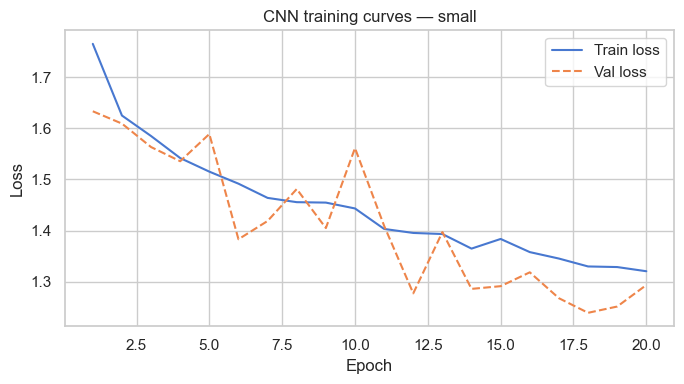

In [27]:
# Training curves
if cnn_train_curves:
    n_plots = len(cnn_train_curves)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    for ax, (sz, (tl, vl)) in zip(axes, cnn_train_curves.items()):
        epochs = range(1, len(tl) + 1)
        ax.plot(epochs, tl, label="Train loss")
        ax.plot(epochs, vl, label="Val loss",  linestyle="--")
        ax.set_title(f"CNN training curves — {sz}")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend()
    plt.tight_layout(); plt.show()
else:
    print("No CNN training curves available (CNN not run).")

In [28]:
# CNN confusion matrix (small dataset if available)
_cnn_sz = next((r["dataset"] for r in cnn_results if r["dataset"] == "small"), None)
if _cnn_sz:
    _cnn_row = next(r for r in cnn_results if r["dataset"] == _cnn_sz)
    _pcf = json.loads(_cnn_row["per_class_f1"])
    _genres_cnn = list(_pcf.keys())
    print(f"CNN [{_cnn_sz}] per-genre F1:")
    for g, v in _pcf.items():
        print(f"  {g}: {v:.3f}")
else:
    print("CNN not run — skipping confusion matrix.")

CNN [small] per-genre F1:
  Electronic: 0.535
  Experimental: 0.508
  Folk: 0.625
  Hip-Hop: 0.621
  International: 0.515
  Pop: 0.204
  Rock: 0.652


---
<a id="dashboard"></a>
## 6. Results Dashboard

In [55]:
# Assemble master_df
_cnn_df = pd.DataFrame(cnn_results) if cnn_results else pd.DataFrame(columns=results_df.columns)
master_df = pd.concat([results_df, _cnn_df], ignore_index=True)

master_df.to_parquet(f"{DATA_ROOT}/results.parquet", index=False)
print("Saved results.parquet")

print(f"master_df: {len(master_df)} rows")
display(master_df.head(3))

Saved results.parquet
master_df: 41 rows


,f1_macro,auroc_macro,precision_macro,recall_macro,train_time_s,n_train,n_test,per_class_f1,dataset,split,features,model,features_dim_raw,features_dim_reduced
0,0.4407,0.8882,0.5240,0.4194,1.44,18907,4727,"{""Blues"": 0.2105, ""Classical"": 0.784, ""Country...",medium,random,Full (518d),Logistic Regression,100,100
1,0.3317,0.8775,0.5979,0.3139,7.61,18907,4727,"{""Blues"": 0.0, ""Classical"": 0.7359, ""Country"":...",medium,random,Full (518d),Random Forest,100,100
2,0.3623,0.9015,0.4360,0.3556,26.86,18907,4727,"{""Blues"": 0.0, ""Classical"": 0.7729, ""Country"":...",medium,random,Full (518d),SVM,100,100


### Chart 1 — F1 Heatmap (all configurations)

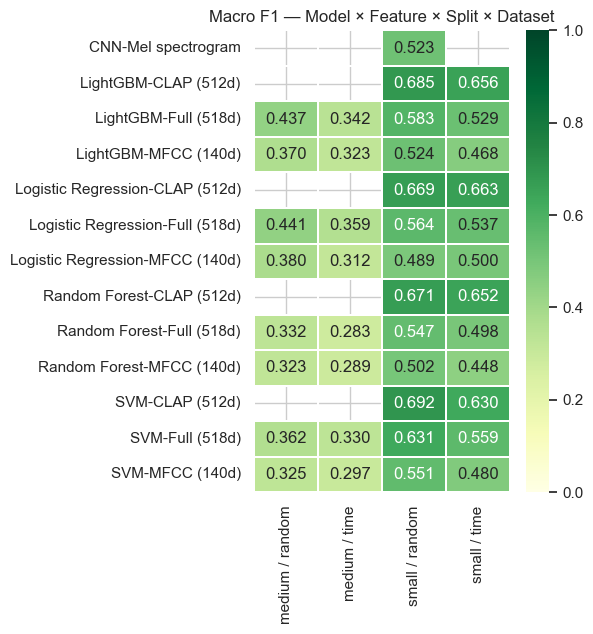

In [56]:
_pivot = master_df.copy()
_pivot["config"] = _pivot["dataset"] + " / " + _pivot["split"]
_heat = _pivot.pivot_table(index=["model", "features"], columns="config", values="f1_macro")

fig, ax = plt.subplots(figsize=(max(6, len(_heat.columns) * 1.5), max(4, len(_heat) * 0.5)))
sns.heatmap(_heat, annot=True, fmt=".3f", cmap="YlGn", vmin=0, vmax=1,
            linewidths=0.3, ax=ax)
ax.set_title("Macro F1 — Model × Feature × Split × Dataset")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Chart 2 — F1 by Model (grouped bar, per feature set)

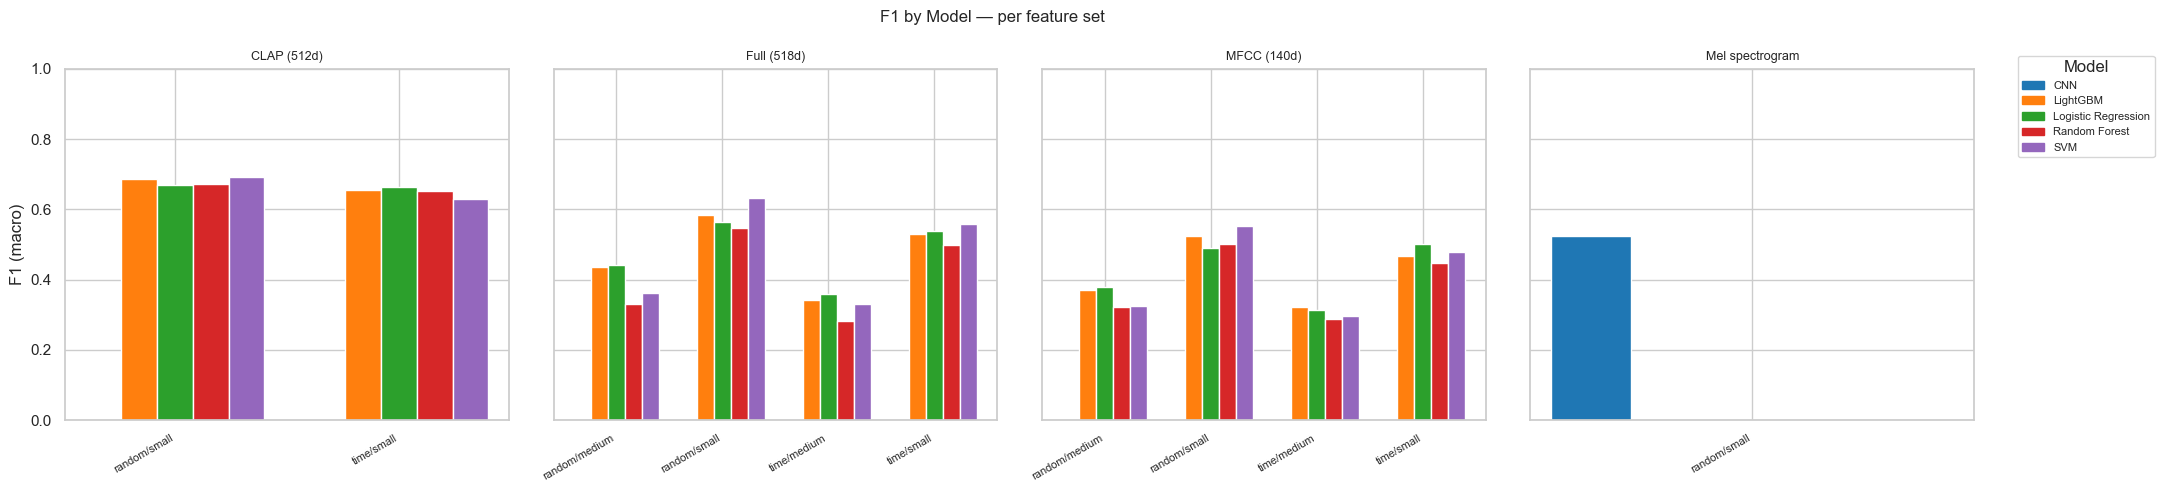

In [57]:
_feats_order = sorted(master_df["features"].unique())
_models_order = sorted(master_df["model"].unique())
_palette = sns.color_palette("tab10", n_colors=len(_models_order))
_color_map = {m: _palette[i] for i, m in enumerate(_models_order)}

fig, axes = plt.subplots(1, len(_feats_order),
                         figsize=(5 * len(_feats_order), 5),
                         sharey=True)
if len(_feats_order) == 1:
    axes = [axes]

for ax, feat in zip(axes, _feats_order):
    sub = master_df[master_df["features"] == feat]
    sub = sub.groupby(["model", "dataset", "split"])["f1_macro"].mean().reset_index()
    sub["group"] = sub["split"] + "/" + sub["dataset"]
    groups = sorted(sub["group"].unique())
    x = np.arange(len(groups))
    w = 0.8 / len(_models_order)
    for mi, model in enumerate(_models_order):
        m_sub = sub[sub["model"] == model].set_index("group").reindex(groups)
        ax.bar(x + mi * w - 0.4 + w / 2, m_sub["f1_macro"].fillna(0),
               width=w, color=_color_map[model], label=model)
    ax.set_xticks(x); ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_title(feat, fontsize=9)
    ax.set_ylim(0, 1)
    if ax is axes[0]:
        ax.set_ylabel("F1 (macro)")

handles = [plt.Rectangle((0,0),1,1, color=_color_map[m]) for m in _models_order]
fig.legend(handles, _models_order, title="Model",
           bbox_to_anchor=(1.01, 0.9), loc="upper left", fontsize=8)
fig.suptitle("F1 by Model — per feature set", fontsize=12)
plt.tight_layout()
plt.show()


### Chart 3 — Metric Radar (per model, best dataset)

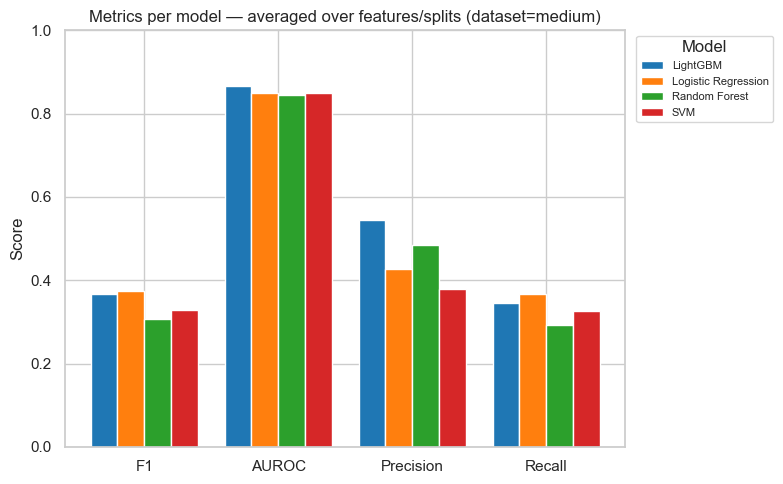

In [58]:
_metrics = ["f1_macro", "auroc_macro", "precision_macro", "recall_macro"]
_metric_labels = ["F1", "AUROC", "Precision", "Recall"]
_best_sz = DATASET_SIZES[-1]

_radar_df = (master_df[master_df["dataset"] == _best_sz]
             .groupby("model")[_metrics].mean().reset_index())

_models_r = _radar_df["model"].tolist()
_palette_r = sns.color_palette("tab10", n_colors=len(_models_r))
x = np.arange(len(_metric_labels))
w = 0.8 / len(_models_r)

fig, ax = plt.subplots(figsize=(8, 5))
for mi, (_, row) in enumerate(_radar_df.iterrows()):
    vals = [row[m] for m in _metrics]
    ax.bar(x + mi * w - 0.4 + w / 2, vals, width=w,
           color=_palette_r[mi], label=row["model"])

ax.set_xticks(x); ax.set_xticklabels(_metric_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title(f"Metrics per model — averaged over features/splits (dataset={_best_sz})")
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


### Chart 4 — Random vs Time-based Split Delta (F1 drop)

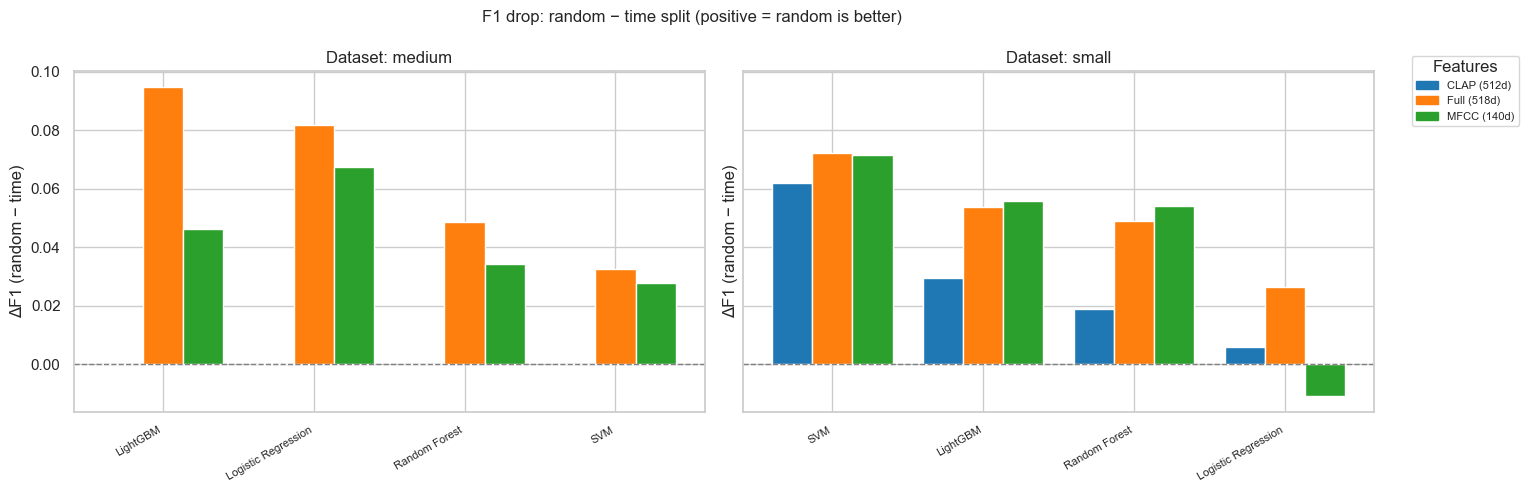

In [59]:
_rand = master_df[master_df["split"] == "random"].set_index(["dataset", "features", "model"])["f1_macro"]
_time = master_df[master_df["split"] == "time"].set_index(["dataset", "features", "model"])["f1_macro"]
_delta = (_rand - _time).dropna().reset_index()
_delta.columns = ["dataset", "features", "model", "f1_delta"]
_delta = _delta.sort_values("f1_delta", ascending=False)

_datasets = sorted(_delta["dataset"].unique())
fig, axes = plt.subplots(1, len(_datasets), figsize=(7 * len(_datasets), 5), sharey=True)
if len(_datasets) == 1:
    axes = [axes]

_feats_u = sorted(_delta["features"].unique())
_palette_d = sns.color_palette("tab10", n_colors=len(_feats_u))
_feat_colors = {f: _palette_d[i] for i, f in enumerate(_feats_u)}

for ax, ds in zip(axes, _datasets):
    sub = _delta[_delta["dataset"] == ds]
    _models_u = sub["model"].unique()
    x = np.arange(len(_models_u))
    w = 0.8 / len(_feats_u)
    for fi, feat in enumerate(_feats_u):
        f_sub = sub[sub["features"] == feat].set_index("model").reindex(_models_u)
        ax.bar(x + fi * w - 0.4 + w / 2, f_sub["f1_delta"].fillna(0),
               width=w, color=_feat_colors[feat], label=feat)
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_xticks(x); ax.set_xticklabels(_models_u, rotation=30, ha="right", fontsize=8)
    ax.set_title(f"Dataset: {ds}")
    ax.set_ylabel("ΔF1 (random − time)")

handles = [plt.Rectangle((0,0),1,1, color=_feat_colors[f]) for f in _feats_u]
fig.legend(handles, _feats_u, title="Features",
           bbox_to_anchor=(1.01, 0.9), loc="upper left", fontsize=8)
fig.suptitle("F1 drop: random − time split (positive = random is better)", fontsize=12)
plt.tight_layout()
plt.show()


### Chart 5 — Small vs Medium Dataset Scatter

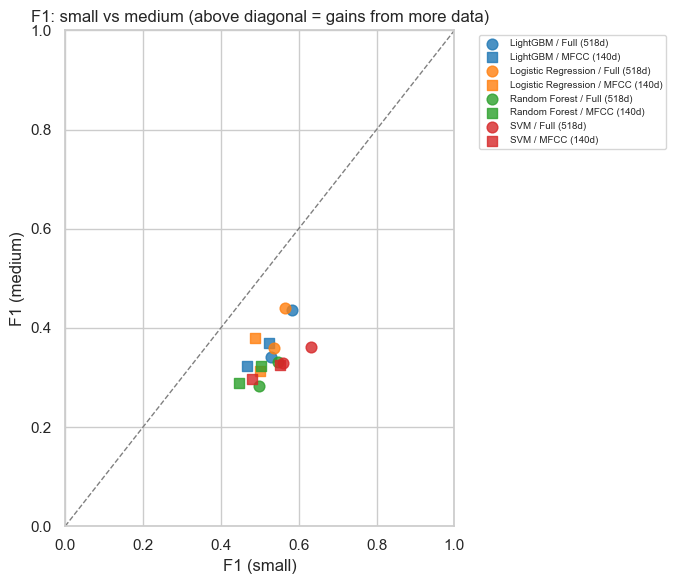

In [60]:
if len(DATASET_SIZES) > 1:
    _sm5 = master_df[master_df["dataset"] == "small"].set_index(["model", "features", "split"])["f1_macro"]
    _md5 = master_df[master_df["dataset"] == "medium"].set_index(["model", "features", "split"])["f1_macro"]
    _cmp5 = pd.DataFrame({"f1_small": _sm5, "f1_medium": _md5}).dropna().reset_index()

    fig, ax = plt.subplots(figsize=(7, 6))
    _palette5 = sns.color_palette("tab10", n_colors=_cmp5["model"].nunique())
    _markers5 = ["o", "s", "^", "D", "v", "P", "*"]
    _feats5 = sorted(_cmp5["features"].unique())
    _models5 = sorted(_cmp5["model"].unique())
    for mi, model in enumerate(_models5):
        for fi, feat in enumerate(_feats5):
            sub = _cmp5[(_cmp5["model"] == model) & (_cmp5["features"] == feat)]
            ax.scatter(sub["f1_small"], sub["f1_medium"],
                       color=_palette5[mi], marker=_markers5[fi % len(_markers5)],
                       label=f"{model} / {feat}", alpha=0.8, s=60)
    ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("F1 (small)"); ax.set_ylabel("F1 (medium)")
    ax.set_title("F1: small vs medium (above diagonal = gains from more data)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print("Only one dataset size — skip.")


### Chart 6 — Training Time vs F1 (efficiency frontier)

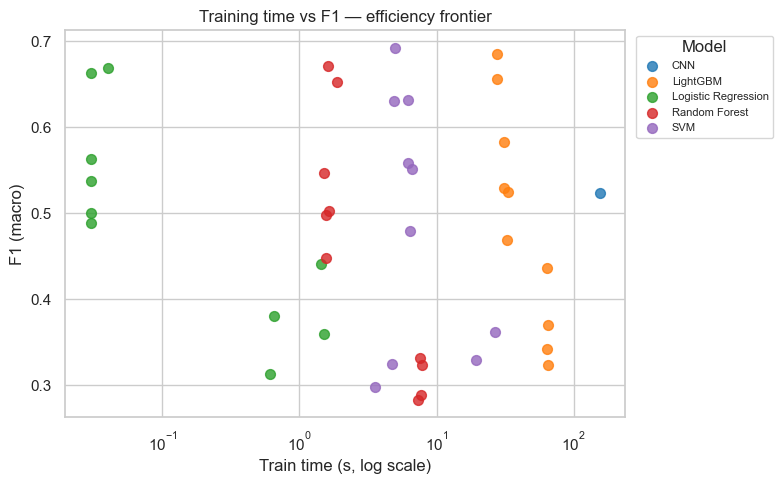

In [61]:
_eff = master_df.dropna(subset=["train_time_s"])
_models_e = sorted(_eff["model"].unique())
_palette_e = sns.color_palette("tab10", n_colors=len(_models_e))

fig, ax = plt.subplots(figsize=(8, 5))
for mi, model in enumerate(_models_e):
    sub = _eff[_eff["model"] == model]
    ax.scatter(sub["train_time_s"], sub["f1_macro"],
               color=_palette_e[mi], label=model, alpha=0.8, s=50)
ax.set_xscale("log")
ax.set_xlabel("Train time (s, log scale)")
ax.set_ylabel("F1 (macro)")
ax.set_title("Training time vs F1 — efficiency frontier")
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


### Chart 7 — Per-Genre F1 Parallel Coordinates

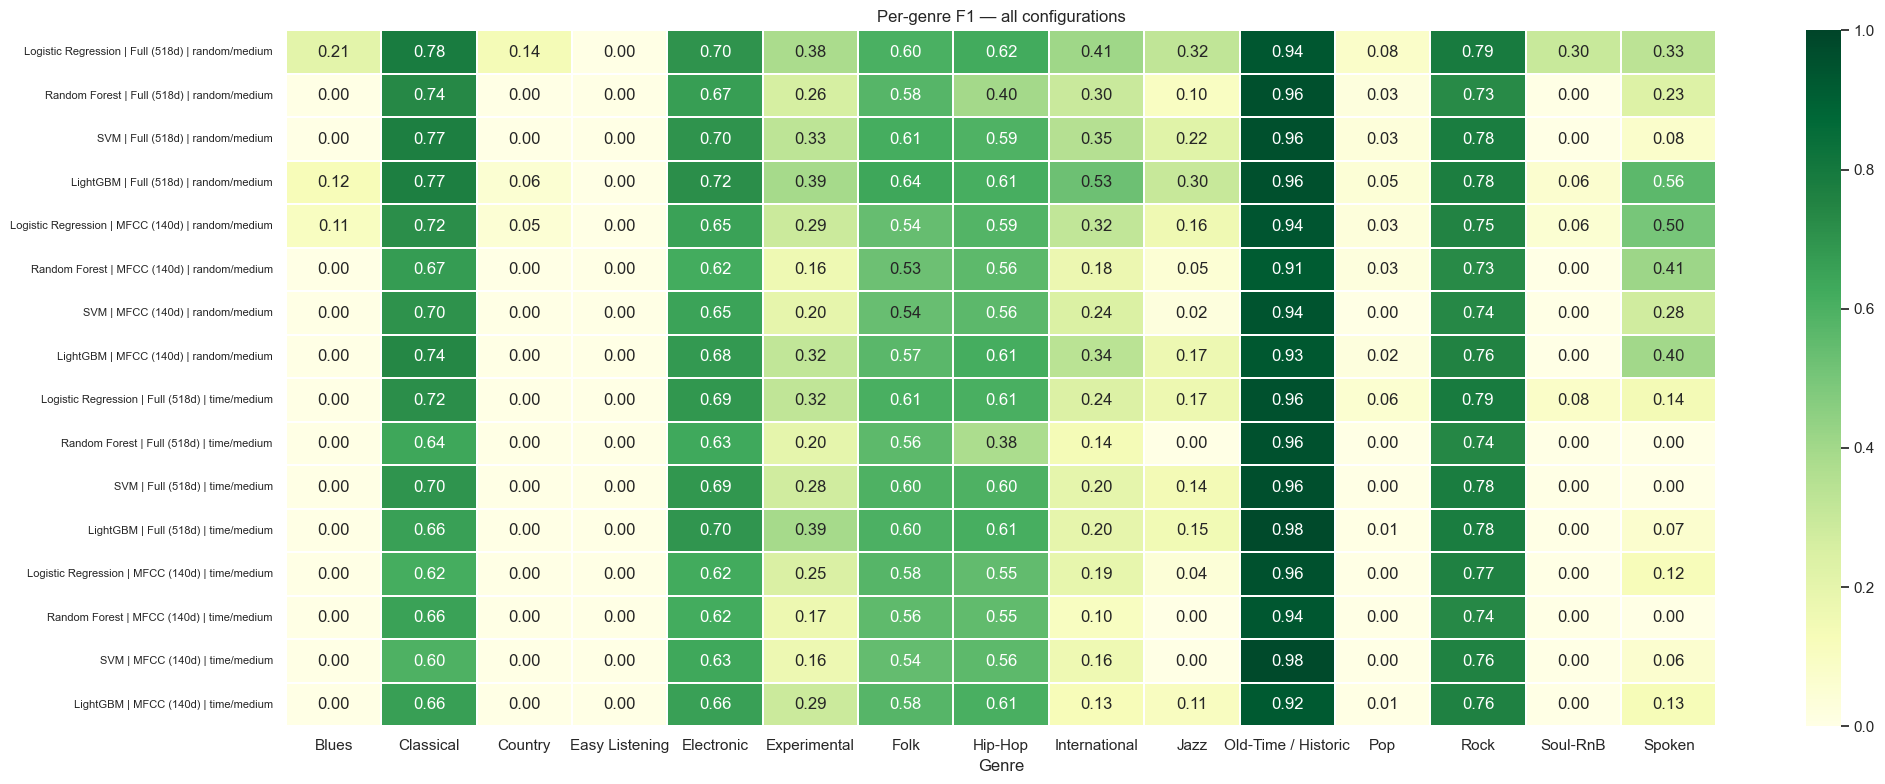

In [62]:
_pcf_df = master_df.copy()
_pcf_expanded = pd.json_normalize(_pcf_df["per_class_f1"].map(json.loads))
_pcf_expanded.index = _pcf_df.index
_genre_cols = _pcf_expanded.columns.tolist()
_pcf_plot = pd.concat([_pcf_df[["model", "features", "split", "dataset"]],
                        _pcf_expanded], axis=1).dropna()

_n_rows = len(_pcf_plot)
_n_cols = len(_genre_cols)
fig, ax = plt.subplots(figsize=(max(10, _n_cols * 1.4), max(4, _n_rows * 0.5)))
_heat2 = _pcf_plot[_genre_cols].astype(float)
_heat2.index = _pcf_plot.apply(
    lambda r: f"{r['model']} | {r['features']} | {r['split']}/{r['dataset']}",
    axis=1,
)
sns.heatmap(_heat2, annot=True, fmt=".2f", cmap="YlGn",
            linewidths=0.2, vmin=0, vmax=1, ax=ax)
ax.set_title("Per-genre F1 — all configurations")
ax.set_xlabel("Genre"); ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


---
<a id="summary"></a>
## 8. Experiment Summary

In [63]:
_top = master_df.sort_values("f1_macro", ascending=False)[
    ["model", "features", "split", "dataset", "f1_macro", "auroc_macro", "train_time_s"]
].reset_index(drop=True)

_summary = f"""
# Experiment Summary — FMA Genre Classification

## Configuration
- **Dataset sizes:** {DATASET_SIZES}
- **Feature sets:** MFCC (140d), Full features (518d), CLAP (512d), Mel spectrogram (CNN only)
- **Splits:** random (stratified 80/20, seed=42), time-based (80th-percentile cutoff)
- **Dimensionality reduction:** {N_COMPONENTS}-component KernelPCA (RBF) or PCA (large datasets), fit on train only
- **Models:** Logistic Regression, Random Forest, SVM, LightGBM, CNN

## Results by Macro F1

{_top.to_markdown(index=True, floatfmt=".3f")}

##   Links
- [1. Data Loading & Exploration](#data-loading)
- [2. Feature Engineering](#features)
- [3. Split × Feature Assembly](#splits)
- [4. Traditional Models — Grid](#grid)
- [5. CNN on Mel Spectrograms](#cnn)
- [6. Results Dashboard](#dashboard)
"""

display(Markdown(_summary))


# Experiment Summary — FMA Genre Classification

## Configuration
- **Dataset sizes:** ['small', 'medium']
- **Feature sets:** MFCC (140d), Full features (518d), CLAP (512d), Mel spectrogram (CNN only)
- **Splits:** random (stratified 80/20, seed=42), time-based (80th-percentile cutoff)
- **Dimensionality reduction:** 100-component KernelPCA (RBF) or PCA (large datasets), fit on train only
- **Models:** Logistic Regression, Random Forest, SVM, LightGBM, CNN

## Results by Macro F1

|    | model               | features        | split   | dataset   |   f1_macro |   auroc_macro |   train_time_s |
|---:|:--------------------|:----------------|:--------|:----------|-----------:|--------------:|---------------:|
|  0 | SVM                 | CLAP (512d)     | random  | small     |      0.692 |         0.924 |          4.950 |
|  1 | LightGBM            | CLAP (512d)     | random  | small     |      0.685 |         0.918 |         27.410 |
|  2 | Random Forest       | CLAP (512d)     | random  | small     |      0.671 |         0.921 |          1.610 |
|  3 | Logistic Regression | CLAP (512d)     | random  | small     |      0.669 |         0.917 |          0.040 |
|  4 | Logistic Regression | CLAP (512d)     | time    | small     |      0.663 |         0.918 |          0.030 |
|  5 | LightGBM            | CLAP (512d)     | time    | small     |      0.656 |         0.904 |         27.390 |
|  6 | Random Forest       | CLAP (512d)     | time    | small     |      0.652 |         0.914 |          1.880 |
|  7 | SVM                 | Full (518d)     | random  | small     |      0.631 |         0.894 |          6.160 |
|  8 | SVM                 | CLAP (512d)     | time    | small     |      0.630 |         0.899 |          4.920 |
|  9 | LightGBM            | Full (518d)     | random  | small     |      0.583 |         0.879 |         31.080 |
| 10 | Logistic Regression | Full (518d)     | random  | small     |      0.564 |         0.874 |          0.030 |
| 11 | SVM                 | Full (518d)     | time    | small     |      0.559 |         0.872 |          6.210 |
| 12 | SVM                 | MFCC (140d)     | random  | small     |      0.551 |         0.867 |          6.630 |
| 13 | Random Forest       | Full (518d)     | random  | small     |      0.547 |         0.869 |          1.500 |
| 14 | Logistic Regression | Full (518d)     | time    | small     |      0.537 |         0.873 |          0.030 |
| 15 | LightGBM            | Full (518d)     | time    | small     |      0.529 |         0.859 |         30.990 |
| 16 | LightGBM            | MFCC (140d)     | random  | small     |      0.524 |         0.852 |         33.340 |
| 17 | CNN                 | Mel spectrogram | random  | small     |      0.523 |         0.855 |        154.900 |
| 18 | Random Forest       | MFCC (140d)     | random  | small     |      0.502 |         0.839 |          1.640 |
| 19 | Logistic Regression | MFCC (140d)     | time    | small     |      0.500 |         0.833 |          0.030 |
| 20 | Random Forest       | Full (518d)     | time    | small     |      0.498 |         0.847 |          1.570 |
| 21 | Logistic Regression | MFCC (140d)     | random  | small     |      0.489 |         0.837 |          0.030 |
| 22 | SVM                 | MFCC (140d)     | time    | small     |      0.480 |         0.825 |          6.360 |
| 23 | LightGBM            | MFCC (140d)     | time    | small     |      0.468 |         0.813 |         32.800 |
| 24 | Random Forest       | MFCC (140d)     | time    | small     |      0.448 |         0.815 |          1.550 |
| 25 | Logistic Regression | Full (518d)     | random  | medium    |      0.441 |         0.888 |          1.440 |
| 26 | LightGBM            | Full (518d)     | random  | medium    |      0.437 |         0.910 |         63.980 |
| 27 | Logistic Regression | MFCC (140d)     | random  | medium    |      0.380 |         0.860 |          0.650 |
| 28 | LightGBM            | MFCC (140d)     | random  | medium    |      0.370 |         0.880 |         64.560 |
| 29 | SVM                 | Full (518d)     | random  | medium    |      0.362 |         0.901 |         26.860 |
| 30 | Logistic Regression | Full (518d)     | time    | medium    |      0.359 |         0.840 |          1.520 |
| 31 | LightGBM            | Full (518d)     | time    | medium    |      0.342 |         0.846 |         64.130 |
| 32 | Random Forest       | Full (518d)     | random  | medium    |      0.332 |         0.877 |          7.610 |
| 33 | SVM                 | Full (518d)     | time    | medium    |      0.330 |         0.836 |         19.340 |
| 34 | SVM                 | MFCC (140d)     | random  | medium    |      0.325 |         0.853 |          4.720 |
| 35 | Random Forest       | MFCC (140d)     | random  | medium    |      0.323 |         0.875 |          7.840 |
| 36 | LightGBM            | MFCC (140d)     | time    | medium    |      0.323 |         0.832 |         64.740 |
| 37 | Logistic Regression | MFCC (140d)     | time    | medium    |      0.312 |         0.812 |          0.610 |
| 38 | SVM                 | MFCC (140d)     | time    | medium    |      0.297 |         0.810 |          3.580 |
| 39 | Random Forest       | MFCC (140d)     | time    | medium    |      0.289 |         0.799 |          7.750 |
| 40 | Random Forest       | Full (518d)     | time    | medium    |      0.283 |         0.826 |          7.320 |

##   Links
- [1. Data Loading & Exploration](#data-loading)
- [2. Feature Engineering](#features)
- [3. Split × Feature Assembly](#splits)
- [4. Traditional Models — Grid](#grid)
- [5. CNN on Mel Spectrograms](#cnn)
- [6. Results Dashboard](#dashboard)
